# Experiment 16: Using LSTM to Predict Future Weather of a City Using Weather Data from Several Other Cities


## Aim
To use an **LSTM (Long Short-Term Memory)** neural network to predict the future temperature of one target city using historical weather data from several other cities.


In [5]:
# Install if needed (run once)
# !pip install numpy pandas matplotlib scikit-learn tensorflow


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

np.random.seed(42)


In [7]:
# Option A: Load your own dataset
# Uncomment and edit the filename if you already have weather data.
# df = pd.read_csv("multi_city_weather.csv", parse_dates=["date"])

# Option B: Create a sample synthetic multi-city weather dataset
days = 500
dates = pd.date_range(start="2022-01-01", periods=days, freq="D")

base = 25 + 8*np.sin(np.linspace(0, 12*np.pi, days))
city_A = base + np.random.normal(0, 1.0, days)
city_B = base + 1.5*np.sin(np.linspace(0, 8*np.pi, days)) + np.random.normal(0, 1.2, days)
city_C = base - 1.0*np.cos(np.linspace(0, 10*np.pi, days)) + np.random.normal(0, 1.1, days)
city_D = base + 0.5*np.sin(np.linspace(0, 15*np.pi, days)) + np.random.normal(0, 0.9, days)

# Target city temperature depends partly on other cities + its own seasonal pattern
target_city_temp = (
    0.30*city_A + 0.25*city_B + 0.20*city_C + 0.15*city_D
    + 2*np.sin(np.linspace(0, 6*np.pi, days))
    + np.random.normal(0, 0.8, days)
)

df = pd.DataFrame({
    "date": dates,
    "city_A_temp": city_A,
    "city_B_temp": city_B,
    "city_C_temp": city_C,
    "city_D_temp": city_D,
    "target_city_temp": target_city_temp
})

df.head()


,date,city_A_temp,city_B_temp,city_C_temp,city_D_temp,target_city_temp
0,2022-01-01,25.496714,26.111413,25.539291,25.700525,22.599662
1,2022-01-02,25.465555,27.970637,25.622898,25.154901,23.490057
2,2022-01-03,26.851883,24.676757,25.277705,25.561692,22.631568
3,2022-01-04,28.320730,27.699050,25.103853,26.934430,24.461710
4,2022-01-05,27.146796,26.900335,27.180537,27.412196,23.203216


In [8]:
print("Dataset shape:", df.shape)
df.info()


Dataset shape: (500, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              500 non-null    datetime64[ns]
 1   city_A_temp       500 non-null    float64       
 2   city_B_temp       500 non-null    float64       
 3   city_C_temp       500 non-null    float64       
 4   city_D_temp       500 non-null    float64       
 5   target_city_temp  500 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 23.6 KB


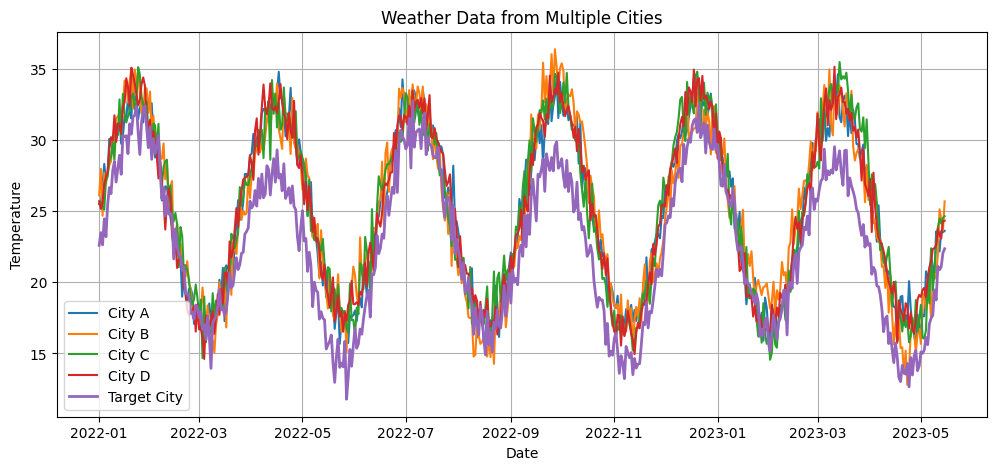

In [9]:
# Plot temperature trends
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["city_A_temp"], label="City A")
plt.plot(df["date"], df["city_B_temp"], label="City B")
plt.plot(df["date"], df["city_C_temp"], label="City C")
plt.plot(df["date"], df["city_D_temp"], label="City D")
plt.plot(df["date"], df["target_city_temp"], label="Target City", linewidth=2)
plt.title("Weather Data from Multiple Cities")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()


## Feature Selection

We will use weather values from several cities as input and the **target city temperature** as the value to predict.


In [10]:
feature_cols = ["city_A_temp", "city_B_temp", "city_C_temp", "city_D_temp", "target_city_temp"]
data = df[feature_cols].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

scaled_data[:5]


array([[0.52295283, 0.56474047, 0.52462512, 0.53983701, 0.51540792],
       [0.52135359, 0.64351447, 0.52861989, 0.51326933, 0.55782906],
       [0.59250796, 0.50395512, 0.51212647, 0.53307691, 0.51692803],
       [0.66789767, 0.63200749, 0.50381976, 0.59991867, 0.60412158],
       [0.60764458, 0.59816654, 0.60304435, 0.62318218, 0.5441631 ]])

## Create Sequences for LSTM

LSTM expects 3D input:
- samples
- time steps
- features

We will use the previous **30 days** to predict the next day's target city temperature.


In [11]:
def create_sequences(dataset, look_back=30, target_index=4):
    X, y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i-look_back:i, :])   # all features for past look_back days
        y.append(dataset[i, target_index])    # target city's next-day temperature
    return np.array(X), np.array(y)

look_back = 30
X, y = create_sequences(scaled_data, look_back=look_back, target_index=4)

print("X shape:", X.shape)  # (samples, time_steps, features)
print("y shape:", y.shape)


X shape: (470, 30, 5)
y shape: (470,)


In [12]:
# Train-test split
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 376
Test samples: 94


## Build the LSTM Model

In [13]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0864 - val_loss: 0.0110
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0296 - val_loss: 0.0040
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0183 - val_loss: 0.0059
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0116 - val_loss: 0.0086
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0085 - val_loss: 0.0052
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0080 - val_loss: 0.0073
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0079 - val_loss: 0.0021
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0066 - val_loss: 0.0024
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0079 - val_loss: 0.0027
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0066 - val_loss: 0.0027
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0077 - val_loss: 0.0017
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

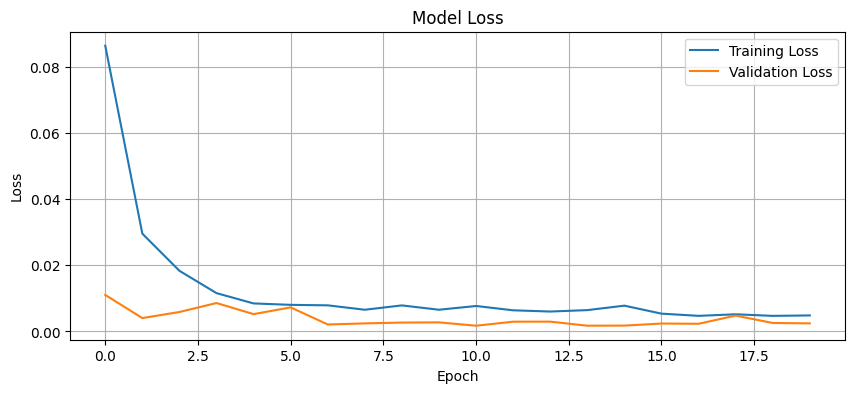

In [15]:
# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## Make Predictions and Convert Back to Real Temperatures

In [16]:
y_pred = model.predict(X_test)

# To inverse transform, rebuild arrays with same number of features
dummy_pred = np.zeros((len(y_pred), len(feature_cols)))
dummy_true = np.zeros((len(y_test), len(feature_cols)))

dummy_pred[:, 4] = y_pred.flatten()
dummy_true[:, 4] = y_test.flatten()

y_pred_actual = scaler.inverse_transform(dummy_pred)[:, 4]
y_test_actual = scaler.inverse_transform(dummy_true)[:, 4]

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)

print("RMSE:", round(rmse, 3))
print("MAE :", round(mae, 3))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
RMSE: 0.831
MAE : 0.679


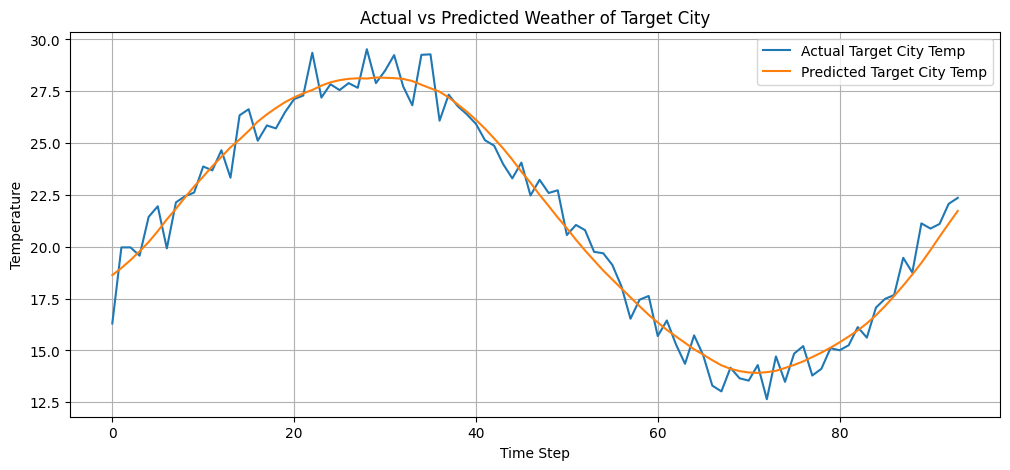

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label="Actual Target City Temp")
plt.plot(y_pred_actual, label="Predicted Target City Temp")
plt.title("Actual vs Predicted Weather of Target City")
plt.xlabel("Time Step")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()


## Predict the Next Day Weather

Use the latest 30-day window to predict the next day's target city temperature.


In [18]:
last_sequence = scaled_data[-look_back:]
last_sequence = np.expand_dims(last_sequence, axis=0)

next_day_scaled = model.predict(last_sequence)

dummy_next = np.zeros((1, len(feature_cols)))
dummy_next[:, 4] = next_day_scaled.flatten()

next_day_temp = scaler.inverse_transform(dummy_next)[:, 4][0]
print("Predicted next day temperature for target city:", round(next_day_temp, 2))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted next day temperature for target city: 22.3


## Accessing and Managing Model Parameters (Weights and Biases)

You can inspect the weights and biases for each layer of your trained model. Each layer has a `get_weights()` method that returns its current weights (which include kernels and biases).

In [19]:
print("\n--- Model Layer Weights and Biases ---")
for i, layer in enumerate(model.layers):
    weights = layer.get_weights()
    if weights:
        print(f"\nLayer {i} ({layer.name}):")
        for j, w in enumerate(weights):
            print(f"  Weight {j} shape: {w.shape}")
            # print(f"  Weight {j} (first 5 values): {w.flatten()[:5]}") # Uncomment to see actual values
    else:
        print(f"\nLayer {i} ({layer.name}): No trainable weights")


--- Model Layer Weights and Biases ---

Layer 0 (lstm):
  Weight 0 shape: (5, 256)
  Weight 1 shape: (64, 256)
  Weight 2 shape: (256,)

Layer 1 (dropout): No trainable weights

Layer 2 (lstm_1):
  Weight 0 shape: (64, 128)
  Weight 1 shape: (32, 128)
  Weight 2 shape: (128,)

Layer 3 (dropout_1): No trainable weights

Layer 4 (dense):
  Weight 0 shape: (32, 16)
  Weight 1 shape: (16,)

Layer 5 (dense_1):
  Weight 0 shape: (16, 1)
  Weight 1 shape: (1,)


### Saving and Loading the Model

The most common and recommended way to save and load all model parameters (including weights and biases, model architecture, and optimizer state) in Keras is to save the entire model.

In [20]:
from tensorflow.keras.models import load_model
import os

# Define a path to save the model
model_save_path = "lstm_weather_predictor.keras"

# Save the entire model
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

# Load the model back
loaded_model = load_model(model_save_path)
print("Model loaded successfully!")

# You can then use the loaded_model for predictions
# For example, let's make a prediction with the loaded model
loaded_y_pred = loaded_model.predict(X_test)

# Verify if predictions are identical (they should be)
print("Predictions from original model match loaded model:", np.allclose(y_pred, loaded_y_pred))

# Clean up the saved model file (optional)
os.remove(model_save_path)
print(f"Cleaned up {model_save_path}")

Model saved to lstm_weather_predictor.keras
Model loaded successfully!
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Predictions from original model match loaded model: True
Cleaned up lstm_weather_predictor.keras
